# Keracunan MBG — EDA & Data Cleaning
Dataset scraped from [Wikipedia: Daftar kasus keracunan makanan massal di dunia](https://id.wikipedia.org/wiki/Daftar_kasus_keracunan_makanan_massal_di_dunia)

**Cleaning steps covered:**
1. Drop trailing summary / empty rows
2. Normalize `tanggal_kejadian` → `dd/mm/yyyy`; unknown dates → `NaN`
3. Drop `meninggal` column (fully empty)
4. Split `bergejala` → `bergejala_count` (int) + `bergejala_unit` (lowercase)
5. Expand compound entries into separate rows

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_PATH   = "/Users/macbook/dataviz_tableau/dataviz_tableau/dataset/keracunan-mbg.csv"
OUTPUT_PATH = "/Users/macbook/dataviz_tableau/dataviz_tableau/dataset/keracunan-mbg-cleaned.csv"

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 20)

In [2]:
df = pd.read_csv(DATA_PATH, dtype=str).fillna("")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (555, 6)


,tanggal_kejadian,provinsi,kabupaten_kota,tempat_sekolah,bergejala,meninggal
0,29 September 2025,Nanggroe Aceh Darussalam,Kabupaten Aceh Utara,SDN 6 Matangkuli,3 Siswa,
1,24 Januari 2026,Nanggroe Aceh Darussalam,Kabupaten Aceh Timur,TBA (Tidak disebutkan),19 Siswa,
2,11 Februari 2026,Nanggroe Aceh Darussalam,Kabupaten Aceh Singkil,TK Bunga Al-Qur’an,16 Santri,
3,11 Februari 2026,Nanggroe Aceh Darussalam,Kabupaten Aceh Singkil,Pesantren Modern Darul Mustafa,17 Santri,
4,15 Oktober 2025,Sumatera Utara,Kabupaten Toba,SD Tanding Laguboti,60 Siswa,
5,15 Oktober 2025,Sumatera Utara,Kabupaten Toba,SMPN 1 Laguboti,61 Siswa,
6,31 Oktober 2025,Sumatera Utara,Kabupaten Nias Utara,SD 071027 Onozitoli Sawo,26 Siswa,
7,9 Februari 2026,Sumatera Utara,Kabupaten Dairi,SMK Swasta HKBP Sidikalang,135 Siswa,
8,9 Februari 2026,Sumatera Utara,Kabupaten Dairi,SMK Swasta Arina Sidikalang,136 Siswa,
9,1 Oktober 2025,Sumatera Barat,Kabupaten Agam,TK (Spesifik tidak disebutkan),24 Siswa,


## 1. Exploratory Data Analysis

In [3]:
print("=== dtypes ===")
print(df.dtypes)
print()
print("=== Empty-string counts ===")
print((df == "").sum())
print()
print("=== Sample rows with any empty field ===")
df[df.eq("").any(axis=1)].head(8)

=== dtypes ===
tanggal_kejadian    object
provinsi            object
kabupaten_kota      object
tempat_sekolah      object
bergejala           object
meninggal           object
dtype: object

=== Empty-string counts ===
tanggal_kejadian      5
provinsi              1
kabupaten_kota        6
tempat_sekolah        6
bergejala             5
meninggal           555
dtype: int64

=== Sample rows with any empty field ===


,tanggal_kejadian,provinsi,kabupaten_kota,tempat_sekolah,bergejala,meninggal
0,29 September 2025,Nanggroe Aceh Darussalam,Kabupaten Aceh Utara,SDN 6 Matangkuli,3 Siswa,
1,24 Januari 2026,Nanggroe Aceh Darussalam,Kabupaten Aceh Timur,TBA (Tidak disebutkan),19 Siswa,
2,11 Februari 2026,Nanggroe Aceh Darussalam,Kabupaten Aceh Singkil,TK Bunga Al-Qur’an,16 Santri,
3,11 Februari 2026,Nanggroe Aceh Darussalam,Kabupaten Aceh Singkil,Pesantren Modern Darul Mustafa,17 Santri,
4,15 Oktober 2025,Sumatera Utara,Kabupaten Toba,SD Tanding Laguboti,60 Siswa,
5,15 Oktober 2025,Sumatera Utara,Kabupaten Toba,SMPN 1 Laguboti,61 Siswa,
6,31 Oktober 2025,Sumatera Utara,Kabupaten Nias Utara,SD 071027 Onozitoli Sawo,26 Siswa,
7,9 Februari 2026,Sumatera Utara,Kabupaten Dairi,SMK Swasta HKBP Sidikalang,135 Siswa,


In [4]:
DATE_RE = re.compile(r"^\d{1,2}\s+\w+\s+\d{4}$")
date_col = df["tanggal_kejadian"]

normal   = date_col.str.match(DATE_RE, na=False)
anomalies = df.loc[~normal, "tanggal_kejadian"].value_counts()
print(f"Normal date format:   {normal.sum()} rows")
print(f"Anomalous / missing:  {(~normal).sum()} rows")
print()
print(anomalies.to_string())

Normal date format:   533 rows
Anomalous / missing:  22 rows

tanggal_kejadian
7 S/d 9 Mei 2025      9
                      5
Tidak Disebutkan      2
Awal Februari 2026    2
Agustus 2025          1
September 2025        1
Januari 2026          1
TOTAL                 1


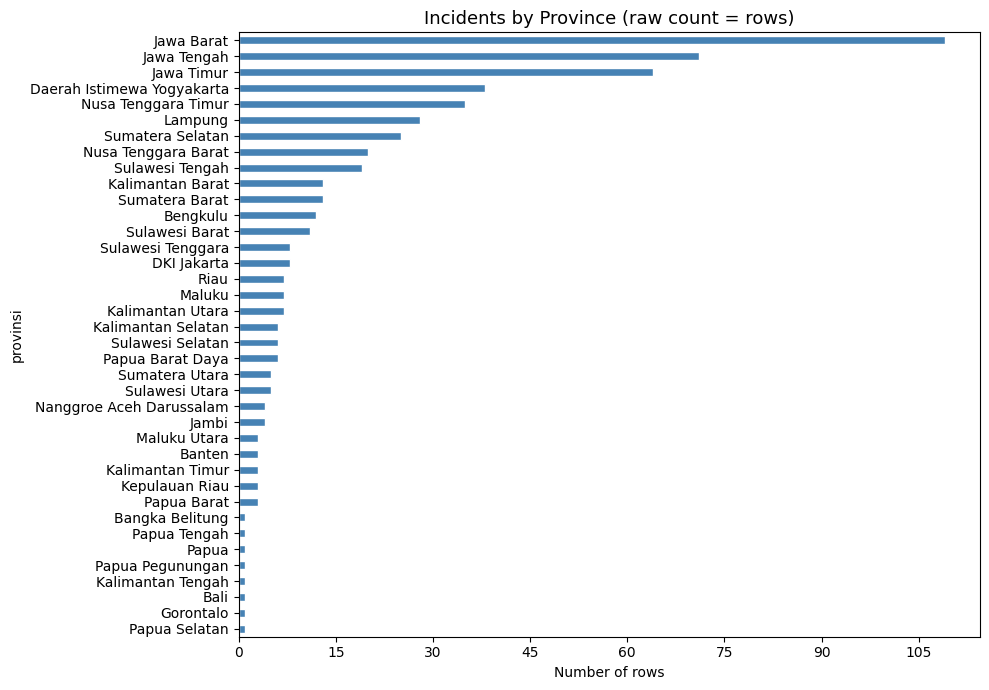

provinsi
Jawa Barat                    109
Jawa Tengah                    71
Jawa Timur                     64
Daerah Istimewa Yogyakarta     38
Nusa Tenggara Timur            35
Lampung                        28
Sumatera Selatan               25
Nusa Tenggara Barat            20
Sulawesi Tengah                19
Kalimantan Barat               13
Sumatera Barat                 13
Bengkulu                       12
Sulawesi Barat                 11
Sulawesi Tenggara               8
DKI Jakarta                     8
Maluku                          7
Kalimantan Utara                7
Riau                            7
Kalimantan Selatan              6
Papua Barat Daya                6
Sulawesi Selatan                6
Sumatera Utara                  5
Sulawesi Utara                  5
Nanggroe Aceh Darussalam        4
Jambi                           4
Banten                          3
Kalimantan Timur                3
Maluku Utara                    3
Kepulauan Riau                  3
Papua

In [5]:
prov_counts = df["provinsi"].replace("", pd.NA).dropna().value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
prov_counts.sort_values().plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Incidents by Province (raw count = rows)", fontsize=13)
ax.set_xlabel("Number of rows")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()
print(prov_counts.to_string())

In [6]:
bg = df["bergejala"].replace("", pd.NA).dropna()

# Classify each value
def classify(v):
    v = str(v).strip()
    if re.match(r"^(puluhan|ratusan|belasan)\b", v, re.I):
        return "vague"
    if re.match(r"^TBA\b", v, re.I):
        return "tba"
    if re.search(r"\+|\bdan\b.*\bdan\b|,.*\d", v, re.I):
        return "compound"
    if re.search(r"[+]|\bdan\b.{1,20}\d", v, re.I):
        return "compound"
    if re.match(r"^[±>~<]", v):
        return "approximate"
    if re.match(r"^\d", v):
        return "clean"
    return "other"

bg_class = bg.apply(classify).value_counts()
print("Bergejala value classification:")
print(bg_class.to_string())
print()

# Show compound samples
compound_mask = df["bergejala"].apply(lambda v: bool(re.search(r"\+|\bdan\b.{1,20}\d", str(v), re.I)))
print(f"\nCompound entries ({compound_mask.sum()} rows):")
print(df.loc[compound_mask, "bergejala"].value_counts().to_string())

Bergejala value classification:
bergejala
clean          520
vague           13
compound         7
tba              5
approximate      5


Compound entries (7 rows):
bergejala
11 Siswa + 1 Guru                        1
342 siswa dan 2 guru                     1
2 Siswa dan 1 Kepala Sekolah             1
75 Siswa dan 5 Guru                      1
135 siswa + 2 guru                       1
48 Siswa, 9 Guru dan 1 Kepala Sekolah    1
25 Siswa dan 1 Balita                    1


## 2. Data Cleaning

### 2.1  Drop trailing summary & fully-empty rows

In [7]:
# Drop rows where tanggal_kejadian is "TOTAL" or provinsi is blank with no school
drop_mask = (
    df["tanggal_kejadian"].str.upper().eq("TOTAL") |
    (df[["tanggal_kejadian","provinsi","kabupaten_kota","tempat_sekolah"]].eq("").all(axis=1))
)
print(f"Dropping {drop_mask.sum()} rows:")
print(df[drop_mask].to_string(index=True))
df = df[~drop_mask].reset_index(drop=True)
print(f"\nRemaining rows: {len(df)}")

Dropping 1 rows:
    tanggal_kejadian provinsi kabupaten_kota tempat_sekolah bergejala meninggal
554            TOTAL                                         ± 11.390          

Remaining rows: 554


### 2.2  Normalize `tanggal_kejadian` → `dd/mm/yyyy`

- Full dates (e.g. `29 September 2025`) → `29/09/2025`
- Month-only (e.g. `Agustus 2025`) → `01/08/2025`
- `Awal Februari 2026` → `01/02/2026`
- Date ranges (e.g. `7 S/d 9 Mei 2025`) → first day only → `07/05/2025`
- `Tidak Disebutkan` / unrecognized → `NaN`

In [8]:
BULAN = {
    "Januari":"01","Februari":"02","Maret":"03","April":"04",
    "Mei":"05","Juni":"06","Juli":"07","Agustus":"08",
    "September":"09","Oktober":"10","November":"11","Desember":"12",
}

def to_dmy(val):
    val = str(val).strip()
    if not val or val.lower() in ("tidak disebutkan", "total"):
        return None
    # Full: "29 September 2025"
    m = re.fullmatch(r"(\d{1,2})\s+(\w+)\s+(\d{4})", val)
    if m:
        d, mon, y = m.groups()
        if mon in BULAN:
            return f"{int(d):02d}/{BULAN[mon]}/{y}"
    # Range: "7 S/d 9 Mei 2025" — take first day
    m = re.fullmatch(r"(\d{1,2})\s+[Ss]/[Dd]\s+\d{1,2}\s+(\w+)\s+(\d{4})", val)
    if m:
        d, mon, y = m.groups()
        if mon in BULAN:
            return f"{int(d):02d}/{BULAN[mon]}/{y}"
    # "Awal Februari 2026"
    m = re.fullmatch(r"Awal\s+(\w+)\s+(\d{4})", val, re.IGNORECASE)
    if m:
        mon, y = m.groups()
        if mon in BULAN:
            return f"01/{BULAN[mon]}/{y}"
    # Month+year only: "Agustus 2025"
    m = re.fullmatch(r"(\w+)\s+(\d{4})", val)
    if m:
        mon, y = m.groups()
        if mon in BULAN:
            return f"01/{BULAN[mon]}/{y}"
    return None  # unrecognized → NaN

df["tanggal_kejadian"] = df["tanggal_kejadian"].apply(to_dmy)

null_dates = df["tanggal_kejadian"].isna().sum()
print(f"Rows with NaN date: {null_dates}")
print()
print("Unique date formats (sample):", df["tanggal_kejadian"].dropna().unique()[:8])

Rows with NaN date: 7

Unique date formats (sample): ['29/09/2025' '24/01/2026' '11/02/2026' '15/10/2025' '31/10/2025'
 '09/02/2026' '01/10/2025' '07/10/2025']


### 2.3  Drop `meninggal` column (fully empty)

In [9]:
df = df.drop(columns=["meninggal"])
print("Columns now:", df.columns.tolist())

Columns now: ['tanggal_kejadian', 'provinsi', 'kabupaten_kota', 'tempat_sekolah', 'bergejala']


### 2.4  Split `bergejala` → `bergejala_count` + `bergejala_unit`

Rules:
- `"39 Siswa"` → `(39, "siswa")`
- `"± 32 Siswa"` → `(32, "siswa")` — strip ±/>/~
- `"1.333 Siswa"` → `(1333, "siswa")` — Indonesian thousand-dot
- Compound (`+` / `, ` / `dan`) → **one row per unit type**, other fields duplicated
- Vague (`Puluhan`, `Ratusan`, `Belasan`, `TBA …`) → `count=NaN`, `unit=original text` — kept for manual review

In [10]:
VAGUE_RE    = re.compile(r"^(puluhan|ratusan|belasan)\b", re.I)
TBA_RE      = re.compile(r"^TBA\b", re.I)
COMPOUND_SEP = re.compile(r"\s*\+\s*|\s*,\s*(?=\d)|\s+dan\s+(?=[\d±>])", re.I)
NUM_UNIT_RE  = re.compile(r"^[±>~<≈]?\s*([\d.,]+)\s*(.*)", re.DOTALL)

def parse_bergejala(text):
    """Return list of (count_int_or_None, unit_str_or_None)."""
    text = str(text).strip() if text and str(text).strip() else ""
    if not text:
        return [(None, None)]
    if VAGUE_RE.match(text) or TBA_RE.match(text):
        return [(None, text)]   # vague — manual review
    parts = COMPOUND_SEP.split(text)
    results = []
    for part in parts:
        part = part.strip()
        if not part:
            continue
        m = NUM_UNIT_RE.match(part)
        if m:
            num_str = m.group(1).replace(".", "").replace(",", ".")
            unit    = m.group(2).strip().lower() or None
            try:
                results.append((round(float(num_str)), unit))
            except ValueError:
                results.append((None, part.lower()))
        else:
            results.append((None, part.lower() if part else None))
    return results if results else [(None, text)]

# Quick test
for sample in ["39 Siswa", "± 32 Siswa", "1.333 Siswa", "11 Siswa + 1 Guru",
               "342 siswa dan 2 guru", "48 Siswa, 9 Guru dan 1 Kepala Sekolah",
               "Puluhan Siswa", "TBA (Tidak Diumumkan)", ""]:
    print(f"  {sample!r:45s} → {parse_bergejala(sample)}")

  '39 Siswa'                                    → [(39, 'siswa')]
  '± 32 Siswa'                                  → [(32, 'siswa')]
  '1.333 Siswa'                                 → [(1333, 'siswa')]
  '11 Siswa + 1 Guru'                           → [(11, 'siswa'), (1, 'guru')]
  '342 siswa dan 2 guru'                        → [(342, 'siswa'), (2, 'guru')]
  '48 Siswa, 9 Guru dan 1 Kepala Sekolah'       → [(48, 'siswa'), (9, 'guru'), (1, 'kepala sekolah')]
  'Puluhan Siswa'                               → [(None, 'Puluhan Siswa')]
  'TBA (Tidak Diumumkan)'                       → [(None, 'TBA (Tidak Diumumkan)')]
  ''                                            → [(None, None)]


In [11]:
BASE_COLS = ["tanggal_kejadian", "provinsi", "kabupaten_kota", "tempat_sekolah"]

rows_out = []
for _, row in df.iterrows():
    parsed = parse_bergejala(row["bergejala"])
    for count, unit in parsed:
        new = {c: row[c] for c in BASE_COLS}
        new["bergejala_count"] = count
        new["bergejala_unit"]  = unit
        rows_out.append(new)

df_clean = pd.DataFrame(rows_out)
df_clean["bergejala_count"] = pd.to_numeric(df_clean["bergejala_count"], errors="coerce")

print(f"Rows before expansion: {len(df)}")
print(f"Rows after expansion:  {len(df_clean)}")
print()
df_clean.dtypes

Rows before expansion: 554
Rows after expansion:  562



tanggal_kejadian     object
provinsi             object
kabupaten_kota       object
tempat_sekolah       object
bergejala_count     float64
bergejala_unit       object
dtype: object

### 2.5  Verify & review

In [12]:
print("=== Null counts ===")
print(df_clean.isna().sum())
print()

# Rows still needing manual review (vague bergejala_count)
vague = df_clean[df_clean["bergejala_count"].isna() & df_clean["bergejala_unit"].notna()]
print(f"Rows with vague/unknown count ({len(vague)} total):")
print(vague["bergejala_unit"].value_counts().head(20).to_string())

=== Null counts ===
tanggal_kejadian     7
provinsi             0
kabupaten_kota       0
tempat_sekolah       0
bergejala_count     23
bergejala_unit       5
dtype: int64

Rows with vague/unknown count (18 total):
bergejala_unit
Puluhan Siswa                      4
Ratusan siswa                      4
TBA (Spesifik tidak disebutkan)    3
Ratusan Siswa                      3
TBA (Tidak Diumumkan)              2
Belasan Siswa                      1
Puluhan siswa                      1


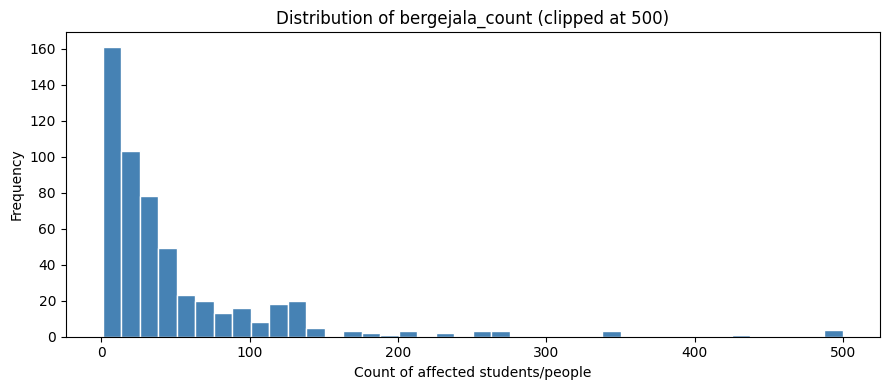

count    539.000000
mean      50.380334
std       75.510026
min        1.000000
25%       12.000000
50%       26.000000
75%       59.000000
max      800.000000
Name: bergejala_count, dtype: float64

In [13]:
# bergejala_count distribution
fig, ax = plt.subplots(figsize=(9, 4))
df_clean["bergejala_count"].dropna().clip(upper=500).plot.hist(
    bins=40, ax=ax, color="steelblue", edgecolor="white"
)
ax.set_title("Distribution of bergejala_count (clipped at 500)")
ax.set_xlabel("Count of affected students/people")
plt.tight_layout()
plt.show()

print(df_clean["bergejala_count"].describe())

In [14]:
# Top units
print("bergejala_unit value counts:")
print(df_clean["bergejala_unit"].value_counts().head(20).to_string())

bergejala_unit value counts:
bergejala_unit
siswa                              489
orang                               21
santri                              11
warga                                7
guru                                 5
Puluhan Siswa                        4
Ratusan siswa                        4
TBA (Spesifik tidak disebutkan)      3
Ratusan Siswa                        3
TBA (Tidak Diumumkan)                2
balita                               2
kepala sekolah                       2
Belasan Siswa                        1
Puluhan siswa                        1
siswa dan guru                       1
anak                                 1


### 2.5  KNN imputation for vague `bergejala` values

Rows with `Belasan Siswa`, `Puluhan Siswa`, `Ratusan Siswa` have no numeric count.

**`KNNImputer` (k=5, distance-weighted)** finds each vague row's 5 nearest non-vague neighbours  
using `provinsi` (encoded) and `tanggal_kejadian` (ordinal), then fills `bergejala_count`  
with their distance-weighted mean — so each row gets a **different** estimate based on its context.  
`bergejala_unit` is set to `"siswa (estimated)"` for all imputed rows.

In [15]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

# ── 1. Identify vague rows ─────────────────────────────────────────────────
vague_mask = df_clean["bergejala_unit"].str.lower().str.contains(
    r"belasan|puluhan|ratusan", na=False
)
print(f"Vague rows to impute: {vague_mask.sum()}")
print(df_clean.loc[vague_mask, ["kabupaten_kota", "bergejala_unit"]].value_counts().to_string())

Vague rows to impute: 13
kabupaten_kota           bergejala_unit
Kabupaten Lampung Timur  Ratusan siswa     3
Kabupaten Ngada          Ratusan Siswa     3
Kabupaten Lampung Utara  Puluhan Siswa     2
Jakarta Utara            Puluhan Siswa     1
Kabupaten Buton          Puluhan Siswa     1
Kabupaten Karanganyar    Ratusan siswa     1
Kabupaten Lombok Timur   Belasan Siswa     1
                         Puluhan siswa     1


In [16]:
# ── 2. Build feature matrix ────────────────────────────────────────────────
work = df_clean[["tanggal_kejadian", "provinsi", "bergejala_count"]].copy()

# Date → ordinal integer
work["date_ord"] = pd.to_datetime(
    work["tanggal_kejadian"], format="%d/%m/%Y", errors="coerce"
).map(lambda d: d.toordinal() if pd.notna(d) else np.nan)

# Province → integer encoding
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
work["prov_enc"] = enc.fit_transform(work[["provinsi"]])

# Set vague rows to NaN so the imputer fills them
work.loc[vague_mask, "bergejala_count"] = np.nan

# ── 3. KNN imputation ──────────────────────────────────────────────────────
X = work[["date_ord", "prov_enc", "bergejala_count"]].values.astype(float)
imputer = KNNImputer(n_neighbors=5, weights="distance")
X_imputed = imputer.fit_transform(X)

# Write back only the vague rows — round to nearest integer
df_clean.loc[vague_mask, "bergejala_count"] = np.round(X_imputed[vague_mask.values, 2])
df_clean.loc[vague_mask, "bergejala_unit"]  = "siswa (estimated)"

print("After KNN imputation — vague rows (each row has a different estimate):")
print(df_clean.loc[vague_mask,
    ["tanggal_kejadian","provinsi","kabupaten_kota","bergejala_count","bergejala_unit"]
].to_string())

After KNN imputation — vague rows (each row has a different estimate):
    tanggal_kejadian             provinsi           kabupaten_kota  bergejala_count     bergejala_unit
74        15/07/2025              Lampung  Kabupaten Lampung Utara             27.0  siswa (estimated)
75        15/07/2025              Lampung  Kabupaten Lampung Utara             27.0  siswa (estimated)
86        28/01/2026              Lampung  Kabupaten Lampung Timur             27.0  siswa (estimated)
87        28/01/2026              Lampung  Kabupaten Lampung Timur             27.0  siswa (estimated)
88        28/01/2026              Lampung  Kabupaten Lampung Timur             27.0  siswa (estimated)
138       08/09/2025          DKI Jakarta            Jakarta Utara             46.0  siswa (estimated)
267       15/10/2025          Jawa Tengah    Kabupaten Karanganyar             61.0  siswa (estimated)
436       19/08/2025  Nusa Tenggara Barat   Kabupaten Lombok Timur             18.0  siswa (estimated)
43

### 2.6  Reconcile `kabupaten_kota` → `shapeName` (geoBoundaries ADM2)

Match each `kabupaten_kota` to `shapeName` in `geoBoundaries-IDN-ADM2.dbf` for Tableau shapefile joins.

**Strategy**
1. Strip `"Kabupaten "` / `"Kota "` prefix → auto-matches most values
2. If the original value (with prefix) is directly in `shapeName` → use it as-is (e.g. `"Kota Baubau"`, `"Kota Yogyakarta"`)
3. Manual map for 10 remaining name discrepancies — all resolvable, 100% coverage

In [17]:
from dbfread import DBF   # pip install dbfread

GEO_DBF = "/Users/macbook/Documents/Data Viz/Spatial/geoBoundaries-IDN-ADM2-all/geoBoundaries-IDN-ADM2.dbf"

shape_names = {r["shapeName"] for r in DBF(GEO_DBF, encoding="utf-8")}
print(f"Unique shapeName in geoBoundaries: {len(shape_names)}")

Unique shapeName in geoBoundaries: 519


In [18]:
import re

def strip_prefix(v):
    return re.sub(r"^(Kabupaten|Kota)\s+", "", str(v).strip())

# Manual corrections: keyed on the stripped value
MANUAL_MAP = {
    # stripped CSV value              : shapeName in geoBoundaries
    "Jakarta Barat"                   : "Kota Jakarta Barat",
    "Jakarta Selatan"                 : "Kota Jakarta Selatan",
    "Jakarta Timur"                   : "Kota Jakarta Timur",
    "Jakarta Utara"                   : "Kota Jakarta Utara",
    "Gunungkidul"                     : "Gunung Kidul",
    "Pangkajene dan Kepulauan"        : "Pangkajene Dan Kepulauan",
    "Timur Tengah Utara"              : "Timor Tengah Utara",   # typo in source
    "Toba"                            : "Toba Samosir",          # kabupaten renamed
    "Tojo Una Una"                    : "Tojo Una-Una",
    "Palangkaraya"                    : "Kota Palangka Raya",
}

def to_shape_name(kab):
    kab = str(kab).strip()
    if not kab:
        return None
    stripped = strip_prefix(kab)

    if kab.startswith("Kota "):
        # Always prefer "Kota X" match to avoid mis-matching city → regency
        # (e.g. "Kota Banjar" must not fall through to plain "Banjar")
        if kab in shape_names:
            return kab
        if stripped in MANUAL_MAP:
            return MANUAL_MAP[stripped]
        if stripped in shape_names:     # last-resort fallback
            return stripped
        return None

    # "Kabupaten X" or no prefix
    if stripped in shape_names:
        return stripped
    if kab in shape_names:              # original matches directly
        return kab
    if stripped in MANUAL_MAP:
        return MANUAL_MAP[stripped]
    return None

df_clean["shape_name"] = df_clean["kabupaten_kota"].apply(to_shape_name)

matched   = df_clean["shape_name"].notna().sum()
unmatched = df_clean["shape_name"].isna().sum()
print(f"Matched rows  : {matched}  ({matched/len(df_clean)*100:.1f}%)")
print(f"Unmatched rows: {unmatched}  ({unmatched/len(df_clean)*100:.1f}%)")

Matched rows  : 557  (99.1%)
Unmatched rows: 5  (0.9%)


In [19]:
# Inspect any remaining unmatched rows
unmatched_df = (
    df_clean[df_clean["shape_name"].isna()]
    [["kabupaten_kota", "provinsi"]]
    .value_counts()
    .reset_index()
)
unmatched_df.columns = ["kabupaten_kota", "provinsi", "row_count"]
if unmatched_df.empty:
    print("All kabupaten_kota values resolved.")
else:
    print(f"Rows with no shapeName match ({unmatched_df['row_count'].sum()} total):")
    print(unmatched_df.to_string(index=False))

Rows with no shapeName match (5 total):
kabupaten_kota         provinsi  row_count
                           Bali          1
                          Papua          1
               Papua Pegunungan          1
                  Papua Selatan          1
                   Papua Tengah          1


In [20]:
# Full mapping reference table
mapping_ref = (
    df_clean[["kabupaten_kota", "shape_name"]]
    .drop_duplicates()
    .sort_values("kabupaten_kota")
    .reset_index(drop=True)
)
print(f"Unique kabupaten_kota → shape_name mappings: {len(mapping_ref)}")
mapping_ref

Unique kabupaten_kota → shape_name mappings: 167


,kabupaten_kota,shape_name
0,,None
1,Jakarta Barat,Kota Jakarta Barat
2,Jakarta Selatan,Kota Jakarta Selatan
3,Jakarta Timur,Kota Jakarta Timur
4,Jakarta Utara,Kota Jakarta Utara
...,...,...
162,Kota Tangerang Selatan,Kota Tangerang Selatan
163,Kota Ternate,Kota Ternate
164,Kota Tomohon,Kota Tomohon
165,Kota Tual,Kota Tual


### 2.7  Save cleaned dataset

In [21]:
df_clean.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(df_clean)} rows → {OUTPUT_PATH}")
df_clean.head(10)

Saved 562 rows → /Users/macbook/dataviz_tableau/dataviz_tableau/dataset/keracunan-mbg-cleaned.csv


,tanggal_kejadian,provinsi,kabupaten_kota,tempat_sekolah,bergejala_count,bergejala_unit,shape_name
0,29/09/2025,Nanggroe Aceh Darussalam,Kabupaten Aceh Utara,SDN 6 Matangkuli,3.0,siswa,Aceh Utara
1,24/01/2026,Nanggroe Aceh Darussalam,Kabupaten Aceh Timur,TBA (Tidak disebutkan),19.0,siswa,Aceh Timur
2,11/02/2026,Nanggroe Aceh Darussalam,Kabupaten Aceh Singkil,TK Bunga Al-Qur’an,16.0,santri,Aceh Singkil
3,11/02/2026,Nanggroe Aceh Darussalam,Kabupaten Aceh Singkil,Pesantren Modern Darul Mustafa,17.0,santri,Aceh Singkil
4,15/10/2025,Sumatera Utara,Kabupaten Toba,SD Tanding Laguboti,60.0,siswa,Toba Samosir
5,15/10/2025,Sumatera Utara,Kabupaten Toba,SMPN 1 Laguboti,61.0,siswa,Toba Samosir
6,31/10/2025,Sumatera Utara,Kabupaten Nias Utara,SD 071027 Onozitoli Sawo,26.0,siswa,Nias Utara
7,09/02/2026,Sumatera Utara,Kabupaten Dairi,SMK Swasta HKBP Sidikalang,135.0,siswa,Dairi
8,09/02/2026,Sumatera Utara,Kabupaten Dairi,SMK Swasta Arina Sidikalang,136.0,siswa,Dairi
9,01/10/2025,Sumatera Barat,Kabupaten Agam,TK (Spesifik tidak disebutkan),24.0,siswa,Agam
